<a href="https://colab.research.google.com/github/KurtGabrielAnduque/CPE-312-BSCPE31S3/blob/main/Activity_2_Training_Linear_Models_ANDUQUE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 312
Code Title: | Predictive Analytics using Machine Learning
1st Semester | AY 2025-2026
<hr> | <hr>
<u>**ACTIVITY NO.** | **Hands-on Activity 2.1 Training Linear Models**
**Name** | Anduque, Kurt Gabriel A.
**Section** | CPE31S3
**Date Performed**: | August 17, 2025
**Date Submitted**: | August 18, 2025
**Instructor**: | Engr. Neal Barton James Matira

<hr>

## 1. Objectives

This activity aims to:
* Perform regression analysis using linear regression and polynomial regression; and
* Solve classification problem using logistic regression.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate how to use Python to predic outcome using linear and polynomial regression;
* Demonstrate how to use single and multiple features to predict the outcome using linear regression;
* Demonstrate how to train and predict classification model using logistic regression;
* Evaluate and visualize the performance of different regression models.

## 3. Procedures and Outputs

### 3.1 Setup

These are configurations for running on your local machine. No problem with running it on your colab. This project requires Python 3.7 or above:

In [ ]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/training_linear_models` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### 3.2 Linear Regression

A linear model makes a prediction by simply computing a weighted sum of the input features, plus a constant called the *bias term* or the *intercept term*.

#### 3.2.1 The Normal Equation

In [ ]:
import numpy as np

np.random.seed(42)  # to make this code example reproducible
m = 100  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector

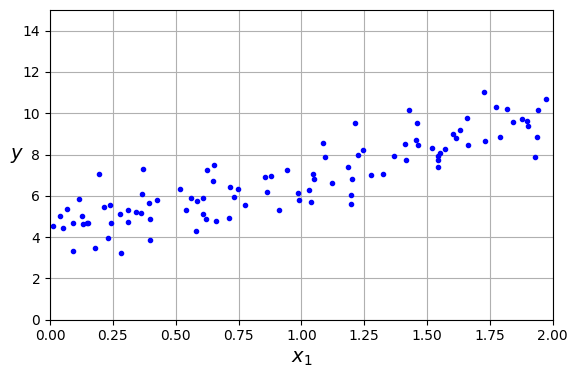

In [ ]:
# extra code – generates and saves Figure 4–1

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

In [ ]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
# USING THE THETA USING THE NORMAL EQUATION
# IT is use for bias and weight for prediction

In [ ]:
theta_best

array([[4.21509616],
       [2.77011339]])

In [ ]:
X_new = np.array([[0], [2]])
# TRY PREDICTING WITH NEW SET OF X
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
# MAKE IT [1 0][1 2]
y_predict = X_new_b @ theta_best
# perform matrix multiplication
y_predict

array([[4.21509616],
       [9.75532293]])

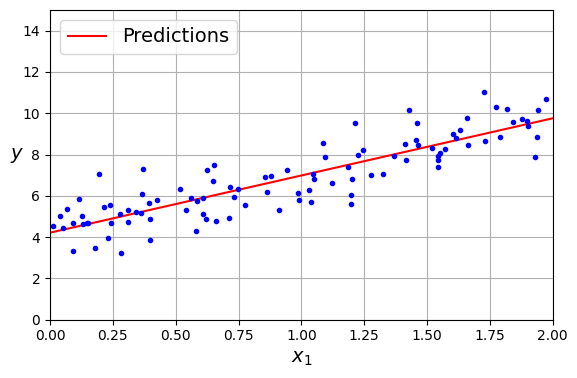

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
# we use the predifined x and y to draw the prediction line
plt.plot(X, y, "b.")

# extra code – beautifies and saves Figure 4–2
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
# using the sklearn library we can also use it to get the theta in linear regression model
# instead of computing it manually using the numpy library
lin_reg = LinearRegression()
lin_reg.fit(X, y)
# the variable we spawn recently using numpy

print(lin_reg.intercept_, lin_reg.coef_)
# if we are going to observe we can clearly see that they have the same value
print('\n')
print(theta_best[0],theta_best[1])

[4.21509616] [[2.77011339]]


[4.21509616] [2.77011339]


In [ ]:
lin_reg.predict(X_new)
# X_new using the [0][2] from recent

array([[4.21509616],
       [9.75532293]])

The `LinearRegression` class is based on the `scipy.linalg.lstsq()` function (the name stands for "least squares"), which you could call directly:

In [ ]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

In [ ]:
print(residuals)
print(rank)
print(s)

[80.6584564]
2
[14.37020392  4.11961067]


The pseudoinverse is computed using a standard matrix factorization technique called *Singular Value Decomposition*. What does SVD do? Quickly research and answer.



This function computes $\mathbf{X}^+\mathbf{y}$, where $\mathbf{X}^{+}$ is the _pseudoinverse_ of $\mathbf{X}$ (specifically the Moore-Penrose inverse). You can use `np.linalg.pinv()` to compute the pseudoinverse directly:

In [ ]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

You have multiple methods used to implement the for linear regression. Provide a comparison between the *Singular Value Decomposition* and the Normal Equation Computation. Which is more efficient?

### 3.2 Gradient Descent

Gradient Descent is a very generic optimization algorithm capable of finding optimal solutions to a wide range of problems. Generally, the idea is to tweak parameters iteratively to minimize a cost funtion.

#### 3.2.1 Batch Gradient Descent

To implement Gradient Descent, you need to compute the gradient of the cost func tion with regards to each model parameter θj. In other words, you need to calculate
how much the cost function will change if you change θj
just a little bit. This is called a partial derivative. It is like asking “what is the slope of the mountain under my feet if I face east?” and then asking the same question facing north (and so on for all other dimensions, if you can imagine a universe with more than three dimensions).

In [ ]:
eta = 0.1  # learning rate
n_epochs = 1000
m = len(X_b)  # number of instances

np.random.seed(42)
theta = np.random.randn(2, 1)  # randomly initialized model parameters

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

The trained model parameters:

In [ ]:
theta

array([[4.21509616],
       [2.77011339]])

In [ ]:
y_predict

array([[4.21509616],
       [9.75532293]])

In [ ]:
X_new

array([[0],
       [2]])

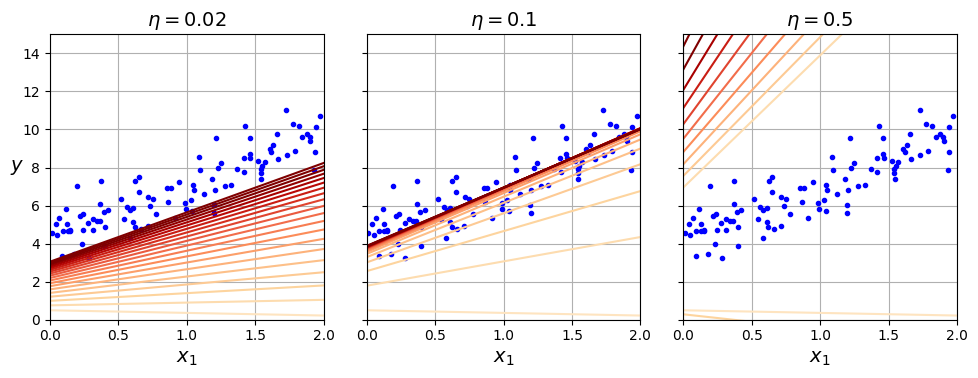

In [ ]:
# extra code – generates and saves Figure 4–8

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

Compare the learning rate provided and shown in the graph above. Provide a quick discussion on how learning rate affects model learning based on the given figure.

<b>Answer:</b>
- With the learning rate it can help in adjusting the stepsize of our regression line in every epoch to reduce the the ***sum of squared residual*** until we reach the optimized solution. We should be careful when assigning a learning rate we must avoid very short steps and very large steps.

<font size= 6>What if, we determine when stop if we have the correct or optimized solution</font>

Converged at epoch 157
Converged at epoch 298
Converged at epoch 106
Converged at epoch 80


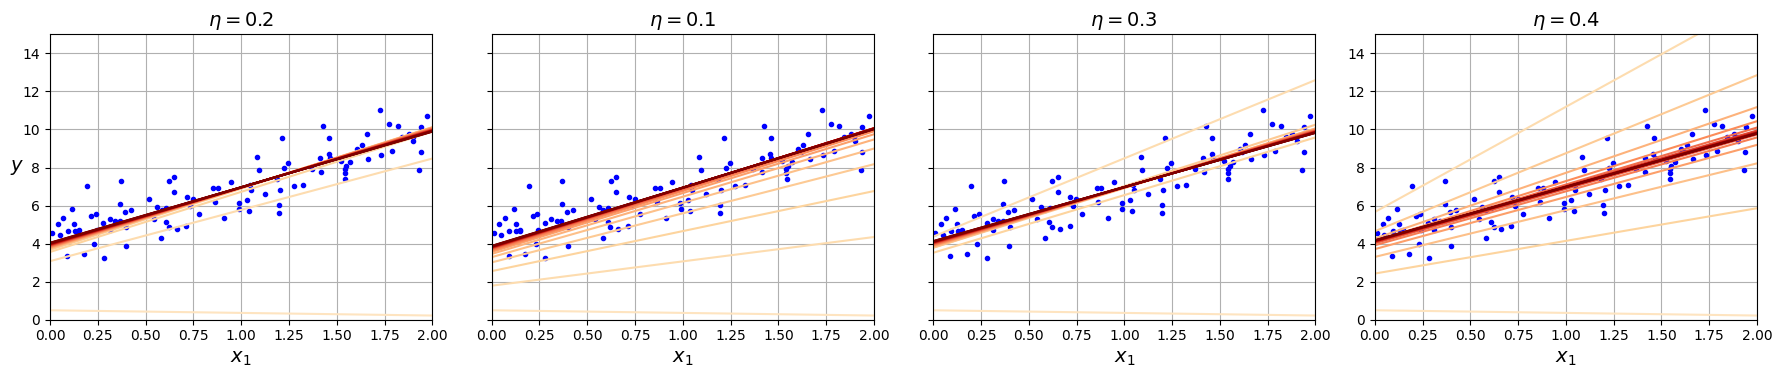

In [ ]:
tolerance = 1e-6  # ADD TOLERANCE

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        new_theta = theta - eta * gradients
        if np.linalg.norm(new_theta - theta, ord=2) < tolerance:
          print("Converged at epoch", epoch)
          break
        theta = new_theta
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

plt.figure(figsize=(18, 4))
plt.subplot(141)
plot_gradient_descent(theta, eta=0.2)
plt.ylabel("$y$", rotation=0)
plt.subplot(142)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(143)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.3)
plt.subplot(144)
plot_gradient_descent(theta, eta=0.4)
save_fig("gradient_descent_plot_ANDUQUE")
plt.show()

#### 3.2.2 Stochastic Gradient Descent

The main problem with Batch Gradient Descent is the fact that it uses the whole training set to compute the gradients at every step, which makes it very slow when
the training set is large. At the opposite extreme, Stochastic Gradient Descent just picks a random instance in the training set at every step and computes the gradients
based only on that single instance. Obviously this makes the algorithm much faster since it has very little data to manipulate at every iteration. It also makes it possible to
train on huge training sets, since only one instance needs to be in memory at each iteration (SGD can be implemented as an out-of-core algorithm.)

In [ ]:
theta_path_sgd = []  # extra code – we need to store the path of theta in the
                     #              parameter space to plot the next figure

[[ 0.49671415]
 [-0.1382643 ]]


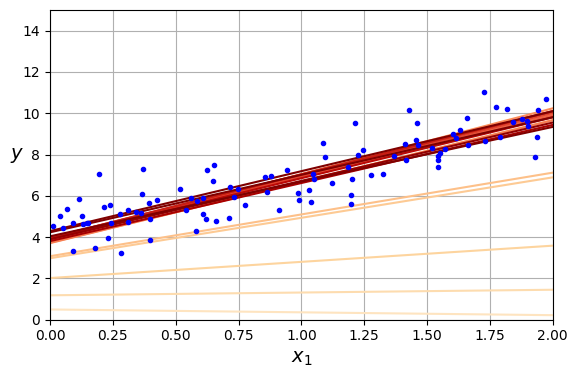

In [ ]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

n_shown = 20  # extra code – just needed to generate the figure below
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting

for epoch in range(n_epochs):
    for iteration in range(m):

        # extra code – these 4 lines are used to generate the figure
        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = np.random.randint(m) # kuha random index
        xi = X_b[random_index : random_index + 1] # hanapin yung value using index
        yi = y[random_index : random_index + 1] # hanapin value using index also
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        #gradients = 2 / m * X_b.T @ (X_b @ theta - y) compare to normal gradient descent
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)  # extra code – to generate the figure

# extra code – this section beautifies and saves Figure 4–10
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("sgd_plot")
plt.show()

In [ ]:
theta

array([[4.21076011],
       [2.74856079]])

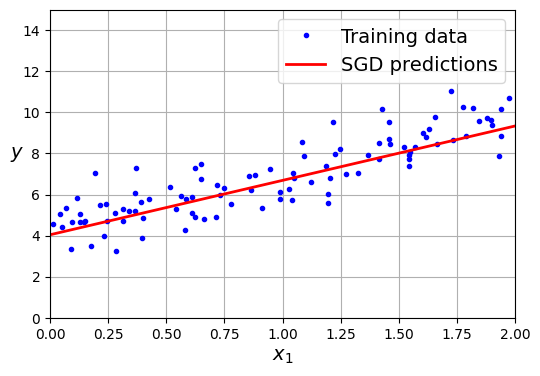

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets

plt.figure(figsize=(6,4))
plt.plot(X, y, "b.", label="Training data")  # blue dots
plt.plot(X_new, y_predict, "r-", linewidth=2, label="SGD predictions")  # red line
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend()
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

In [ ]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

Compare the Stochastic Gradient Descent used in this section to the gradient descent algorithm used previously. What are the benefits to using Stochastic Gradient Descent (SGD)?

<b>Answer: </b>
- If we are dealing with a large number of data like millions, using gradient descent will in finding the optimal solution would be very slow since it has to ready every daompared to stochta in every epoch. Castic gradient descent wherein every iteration get only 1 random sample for calculating the step size.

#### 3.2.3 Mini-batch gradient descent

The last Gradient Descent algorithm we will look at is called Mini-batch Gradient Descent. It is quite simple to understand once you know Batch and Stochastic Gradient Descent: at each step, instead of computing the gradients based on the full training set (as in Batch GD) or based on just one instance (as in Stochastic GD), Minibatch GD computes the gradients on small random sets of instances called minibatches. The main advantage of Mini-batch GD over Stochastic GD is that you can get a performance boost from hardware optimization of matrix operations, especially
when using GPUs.

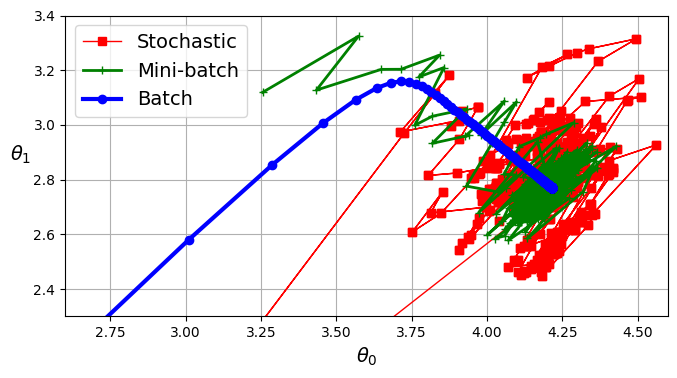

In [ ]:
# extra code – this cell generates and saves Figure 4–11

from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

t0, t1 = 200, 1000  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.6, 4.6, 2.3, 3.4])
plt.grid()
save_fig("gradient_descent_paths_plot")
plt.show()

Provide a comparison of the 3 gradient descent algorithms included in this section. The comparison must provide an analysis based on different factors such as execution time (among others).

<b>Answer:</b>
- Batch Gradient Descent processes the whole dataset to calculate gradients each time which ensures stability yet runs at a slower pace when processing big datasets. Stochastic Gradient Descent performs parameter updates after processing each individual data point which results in quicker iteration times but produces unstable and noisy convergence patterns. Mini-Batch Gradient Descent finds balance between batch and stochastic methods by processing gradient calculations on small mini-batches of data which delivers moderate execution speeds alongside better stability than pure SGD and faster convergence than full batch processing. The selection between these methods depends on dataset dimensions along with available computing power and the required speed-to-stability ratio.

### 3.3 Polynomial Regression

What if your data is actually more complex than a simple straight line? Surprisingly, you can actually use a linear model to fit nonlinear data. A simple way to do this is to
add powers of each feature as new features, then train a linear model on this extended set of features. This technique is called Polynomial Regression.

In [ ]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

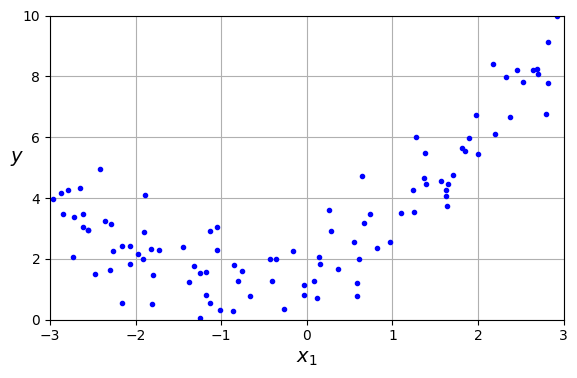

In [ ]:
# extra code – this cell generates and saves Figure 4–12
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_data_plot")
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [ ]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

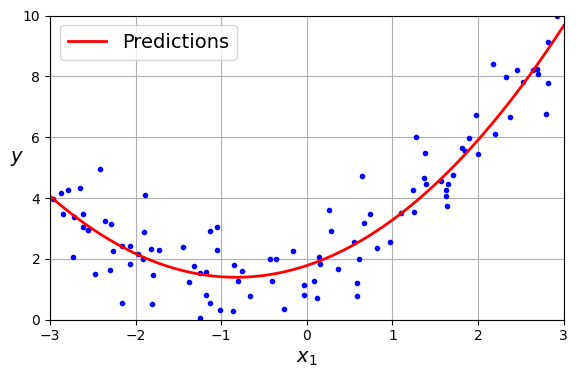

In [ ]:
# extra code – this cell generates and saves Figure 4–13

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("quadratic_predictions_plot")
plt.show()

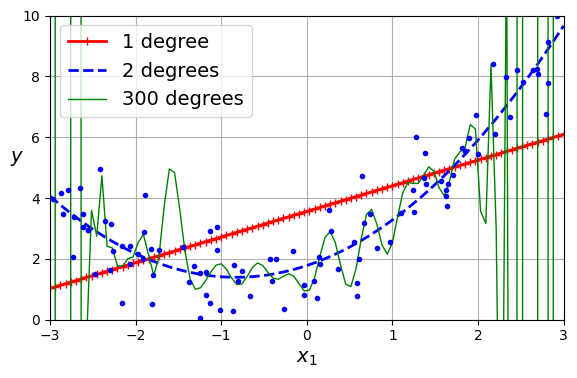

In [ ]:
# extra code – this cell generates and saves Figure 4–14

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(6, 4))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 300)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
save_fig("high_degree_polynomials_plot")
plt.show()

Based on this example, how is Polynomial Regression able to find relationships between features? Is this something simple Linear Regression is unable to do?
- Polynomial Regression can follow curve patterns between features by expanding the degree of our input variables. Which is something that a Linear Regression can't do since it follows a straight line.

What do we achieve in the figure above? Explain the result of the comparison.
- Base on the figure above upon experimenting the degree of polynomial. We are able to create and demostrate under fitting, over fitting, and just right machine learning models.

### 3.4 Learning Curves

If you perform high-degree Polynomial Regression, you will likely fit the training data much better than with plain Linear Regression.

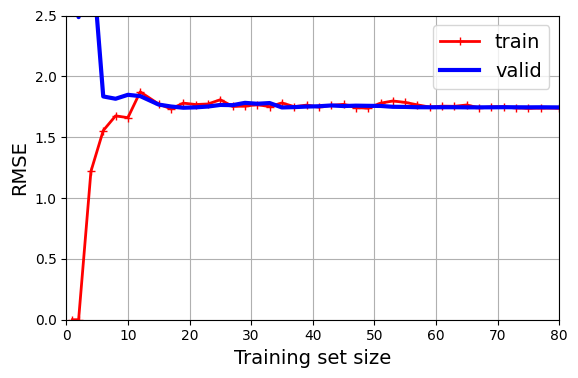

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
save_fig("underfitting_learning_curves_plot")

plt.show()

This deserves a bit of explanation. First, let’s look at the performance on the training data: when there are just one or two instances in the training set, the model can fit
them perfectly, which is why the curve starts at zero. But as new instances are added to the training set, it becomes impossible for the model to fit the training data perfectly, both because the data is noisy and because it is not linear at all. So the error on the training data goes up until it reaches a plateau, at which point adding new instances to the training set doesn’t make the average error much better or worse.


Now let’s look at the performance of the model on the validation data. When the model is trained on very few training instances, it is incapable of generalizing properly, which is why the validation error is initially quite big. Then as the model is shown more training examples, it learns and thus the validation error slowly goes down. However, once again a straight line cannot do a good job modeling the data, so the error ends up at a plateau, very close to the other curve.

What are these learning curves indicating? Is the model overfitting or underfitting? Explain why.
- I believe this to be an instance of underfitting based on the learning curves figure above. The model's inability to reduce error to manageable margins during both training and validation is its main weakness. The model was able to reduce the error during the validation process, but it instead plateaued along the opposite curve. In summary, the data patterns were not learned by the model. It might not be complex enough to model the nonlinear relationship.

In [ ]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

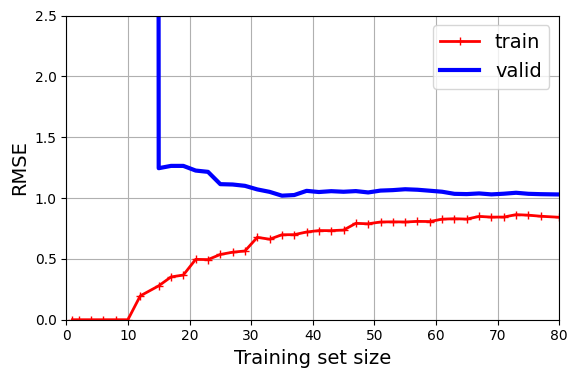

In [ ]:
# extra code – generates and saves Figure 4–16

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
save_fig("learning_curves_plot")
plt.show()

Compare this learning curve with the one previously shown above. The major differences you must explain here are as follows:

* The learning rate
* The gap between the curves

<b>Answer:</b>
- An illustration of overfitting can be seen in the graph above. The reason for this is the wide space between the curves. Because the error did not even manage to drop below its training, the gap between the train and valid plot indicates that the model only performs well on the "seen" data. The validation error begins high and gradually drops for its learning rate. This indicates that the model is learning more quickly and efficiently than it was previously.

### 3.5 Regularized Linear Models

a good way to reduce overfitting is to regularize the model (i.e., to constrain it): the fewer degrees of freedom it has, the harder it will be for it to overfit the data. For example, a simple way to regularize a polynomial model is to reduce the number of polynomial degrees.

#### 3.5.1 Ridge Regression

For a linear model, regularization is typically achieved by constraining the weights of the model. We will now look at Ridge Regression, Lasso Regression, and Elastic Net, which implement three different ways to constrain the weights.

This forces the learning algorithm to not only fit the data but also keep the model weights as small as possible. Note that the regularization term should only be added to the cost function during training. Once the model is trained, you want to evaluate the model’s performance using the unregularized performance measure.

Let's generate a very small and noisy linear dataset:

In [ ]:
# extra code – we've done this type of generation several times before
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

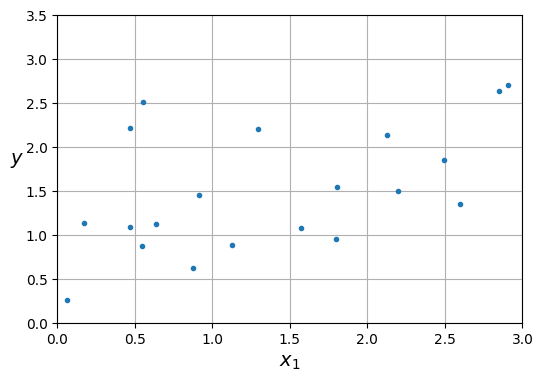

In [ ]:
# extra code – a quick peek at the dataset we just generated
plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55325833]])

As with Linear Regression, we can perform Ridge Regression either by computing a closed-form equation or by performing Gradient Descent. The pros and cons are the same.

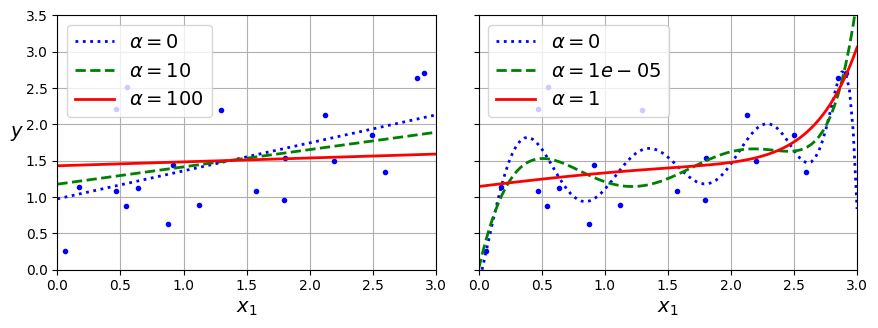

In [ ]:
# extra code – this cell generates and saves Figure 4–17

def plot_model(model_class, polynomial, alphas, **model_kwargs):
    plt.plot(X, y, "b.", linewidth=3)
    for alpha, style in zip(alphas, ("b:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        if polynomial:
            model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                model)
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([0, 3, 0, 3.5])
    plt.grid()

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
save_fig("ridge_regression_plot")
plt.show()

In [ ]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                       max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets
sgd_reg.predict([[1.5]])

array([1.55302613])

In [ ]:
# extra code – show that we get roughly the same solution as earlier when
#              we use Stochastic Average GD (solver="sag")
ridge_reg = Ridge(alpha=0.1, solver="sag", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55326019]])

In [ ]:
# extra code – shows the closed form solution of Ridge regression,
#              compare with the next Ridge model's learned parameters below
alpha = 0.1
A = np.array([[0., 0.], [0., 1.]])
X_b = np.c_[np.ones(m), X]
np.linalg.inv(X_b.T @ X_b + alpha * A) @ X_b.T @ y

array([[0.97898394],
       [0.3828496 ]])

In [ ]:
ridge_reg.intercept_, ridge_reg.coef_  # extra code

(array([0.97896386]), array([[0.38286422]]))

Discuss the following:
* What is the purpose of the hyperparameter alpha as seen in the figures above?
* Suppose you are using Ridge Regression and you notice that the training error and the validation error are almost equal and fairly high. Would you say that the model suffers from high bias or high variance? Should you increase the regularization hyperparameter α or reduce it?

<b>Answer</b>
- Based on the graph above, I believe that the model's fitting to the data points is controlled by the hyperparameter alpha. It smoothes fitting by controlling bias and variance with the penalty.

- Given the circumstances, it would be an instance of underfitting, with a low variance and a high bias. The fact that the training and validation errors are equal and relatively high suggests that the model did not learn. To counteract this, we can reduce bias and increase variance by lowering the hyperparameter.

#### 3.5.2 Lasso Regression

Least Absolute Shrinkage and Selection Operator Regression (simply called Lasso Regression) is another regularized version of Linear Regression: just like Ridge Regression, it adds a regularization term to the cost function, but it uses the ℓ1 norm of the weight vector instead of half the square of the ℓ2 norm.

In [ ]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

An important characteristic of Lasso Regression is that it tends to completely eliminate the weights of the least important features (i.e., set them to zero).

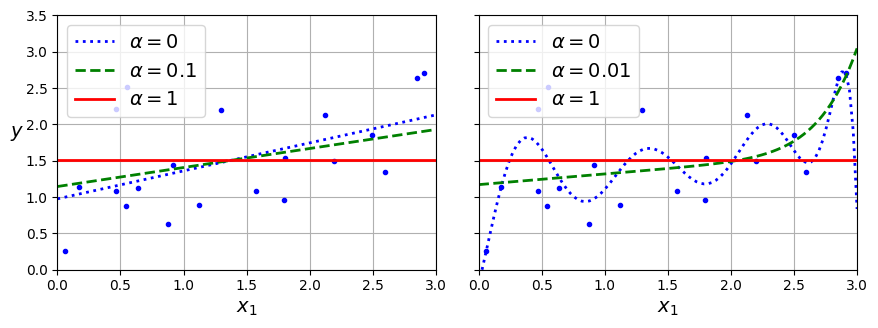

In [ ]:
# extra code – this cell generates and saves Figure 4–18
plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
save_fig("lasso_regression_plot")
plt.show()

For example, the dashed line in the right plot on Figure 4-18 (with α = 10-7) looks quadratic, almost linear: all the weights for the high-degree polynomial features are equal to zero. In other words, Lasso Regression automatically performs feature selection and outputs a
sparse model (i.e., with few nonzero feature weights).

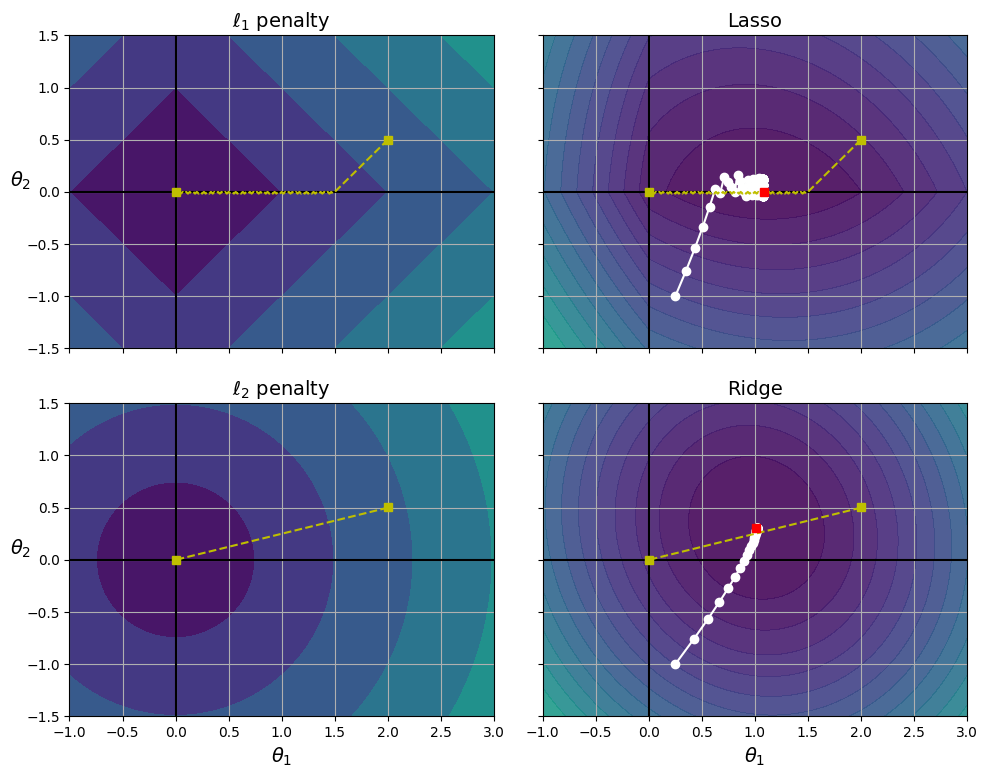

In [ ]:
# extra code – this BIG cell generates and saves Figure 4–19

t1a, t1b, t2a, t2b = -1, 3, -1.5, 1.5

t1s = np.linspace(t1a, t1b, 500)
t2s = np.linspace(t2a, t2b, 500)
t1, t2 = np.meshgrid(t1s, t2s)
T = np.c_[t1.ravel(), t2.ravel()]
Xr = np.array([[1, 1], [1, -1], [1, 0.5]])
yr = 2 * Xr[:, :1] + 0.5 * Xr[:, 1:]

J = (1 / len(Xr) * ((T @ Xr.T - yr.T) ** 2).sum(axis=1)).reshape(t1.shape)

N1 = np.linalg.norm(T, ord=1, axis=1).reshape(t1.shape)
N2 = np.linalg.norm(T, ord=2, axis=1).reshape(t1.shape)

t_min_idx = np.unravel_index(J.argmin(), J.shape)
t1_min, t2_min = t1[t_min_idx], t2[t_min_idx]

t_init = np.array([[0.25], [-1]])

def bgd_path(theta, X, y, l1, l2, core=1, eta=0.05, n_iterations=200):
    path = [theta]
    for iteration in range(n_iterations):
        gradients = (core * 2 / len(X) * X.T @ (X @ theta - y)
                     + l1 * np.sign(theta) + l2 * theta)
        theta = theta - eta * gradients
        path.append(theta)
    return np.array(path)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10.1, 8))

for i, N, l1, l2, title in ((0, N1, 2.0, 0, "Lasso"), (1, N2, 0, 2.0, "Ridge")):
    JR = J + l1 * N1 + l2 * 0.5 * N2 ** 2

    tr_min_idx = np.unravel_index(JR.argmin(), JR.shape)
    t1r_min, t2r_min = t1[tr_min_idx], t2[tr_min_idx]

    levels = np.exp(np.linspace(0, 1, 20)) - 1
    levelsJ = levels * (J.max() - J.min()) + J.min()
    levelsJR = levels * (JR.max() - JR.min()) + JR.min()
    levelsN = np.linspace(0, N.max(), 10)

    path_J = bgd_path(t_init, Xr, yr, l1=0, l2=0)
    path_JR = bgd_path(t_init, Xr, yr, l1, l2)
    path_N = bgd_path(theta=np.array([[2.0], [0.5]]), X=Xr, y=yr,
                      l1=np.sign(l1) / 3, l2=np.sign(l2), core=0)
    ax = axes[i, 0]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, N / 2.0, levels=levelsN)
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.set_title(fr"$\ell_{i + 1}$ penalty")
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$", rotation=0)

    ax = axes[i, 1]
    ax.grid()
    ax.axhline(y=0, color="k")
    ax.axvline(x=0, color="k")
    ax.contourf(t1, t2, JR, levels=levelsJR, alpha=0.9)
    ax.plot(path_JR[:, 0], path_JR[:, 1], "w-o")
    ax.plot(path_N[:, 0], path_N[:, 1], "y--")
    ax.plot(0, 0, "ys")
    ax.plot(t1_min, t2_min, "ys")
    ax.plot(t1r_min, t2r_min, "rs")
    ax.set_title(title)
    ax.axis([t1a, t1b, t2a, t2b])
    if i == 1:
        ax.set_xlabel(r"$\theta_1$")

save_fig("lasso_vs_ridge_plot")
plt.show()

Using the figure above, compare the Lasso Regression and the Ridge Regression. What kind of performance is observable from the graph?
<b>Answer:</b>
- the figure above demonstrates that Lasso induces sparsity through its penalty, which is reflected in the solution path moving towards zero coefficients, while Ridge continuously shrinks coefficients without nullifying them, favored for stable, less sparse models.

### 3.6 Early Stopping

A very different way to regularize iterative learning algorithms such as Gradient Descent is to stop training as soon as the validation error reaches a minimum. This is called early stopping.

Let's go back to the quadratic dataset we used earlier:

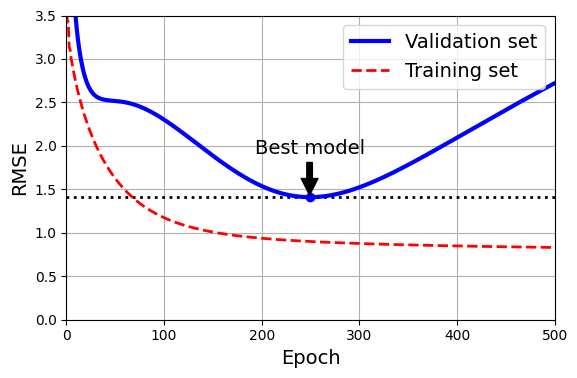

In [ ]:
from copy import deepcopy
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# extra code – creates the same quadratic dataset as earlier and splits it
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  # extra code – it's for the figure below

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = mean_squared_error(y_valid, y_valid_predict, squared=False)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = mean_squared_error(y_train, y_train_predict, squared=False)
    val_errors.append(val_error)
    train_errors.append(train_error)

# extra code – this section generates and saves Figure 4–20
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()
save_fig("early_stopping_plot")
plt.show()

Do you foresee any useful benefits of implementing early stopping?
- Early stopping has the advantage of avoiding time waste when computing. This is due to the fact that when the model reaches its optimal fit, early stopping stops additional computations. Additionally, early stopping can prevent overfitting by preventing the model from finding a better error rate, which will ultimately result in memorization. Early stopping aids in the model's ability to balance its bias and variance and identify an appropriate stopping point.

### 3.7 Logistic Regression

Logistic Regression (also called Logit Regression) is com‐
monly used to estimate the probability that an instance belongs to a particular class (e.g., what is the probability that this email is spam?). If the estimated probability is greater than 50%, then the model predicts that the instance belongs to that class (called the positive class, labeled “1”), or else it predicts that it does not (i.e., it belongs to the negative class, labeled “0”). This makes it a binary classifier.

#### 3.7.1 Estimating Probabilities

So how does it work? Just like a Linear Regression model, a Logistic Regression model computes a weighted sum of the input features (plus a bias term), but instead of outputting the result directly like the Linear Regression model does, it outputs the logistic of this result.

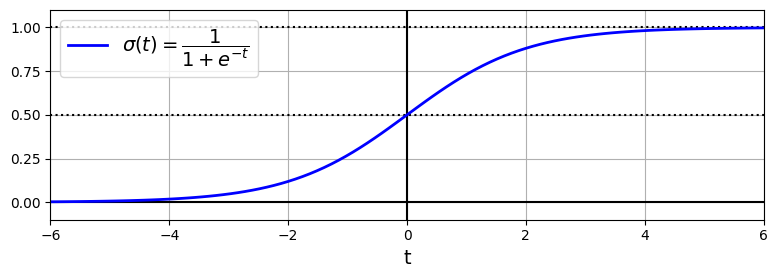

In [ ]:
# extra code – generates and saves Figure 4–21

lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k-")
plt.plot([-lim, lim], [0.5, 0.5], "k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left")
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()
save_fig("logistic_function_plot")
plt.show()

Given the figure above, explain how the equation might be interpreted as the figure and how this provides a logistic regression prediction?
- The equation can be used to determine probability within 0 or 1, as the above figure illustrates. This aids in converting a regression model's linear output into a probability. This aids in the solution of the binary classification problem.

#### 3.7.2 Decision Boundaries

Let’s use the iris dataset to illustrate Logistic Regression. This is a famous dataset that contains the sepal and petal length and width of 150 iris flowers of three different species: Iris-Setosa, Iris-Versicolor, and Iris-Virginica

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [ ]:
print(iris.DESCR)  # extra code – it's a bit too long

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [ ]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [ ]:
iris.target.head(3)  # note that the instances are not shuffled

0    0
1    0
2    0
Name: target, dtype: int64

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

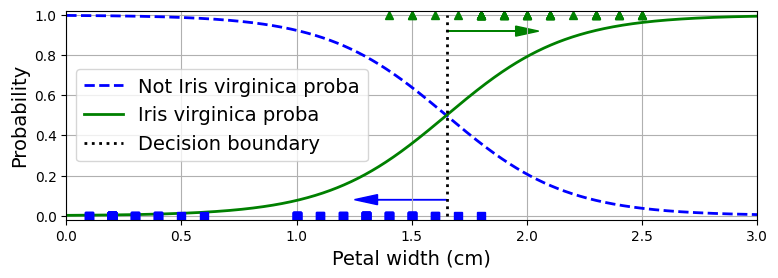

In [ ]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

# extra code – this section beautifies and saves Figure 4–23
plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
save_fig("logistic_regression_plot")

plt.show()

In [ ]:
decision_boundary

1.6516516516516517

In [ ]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])

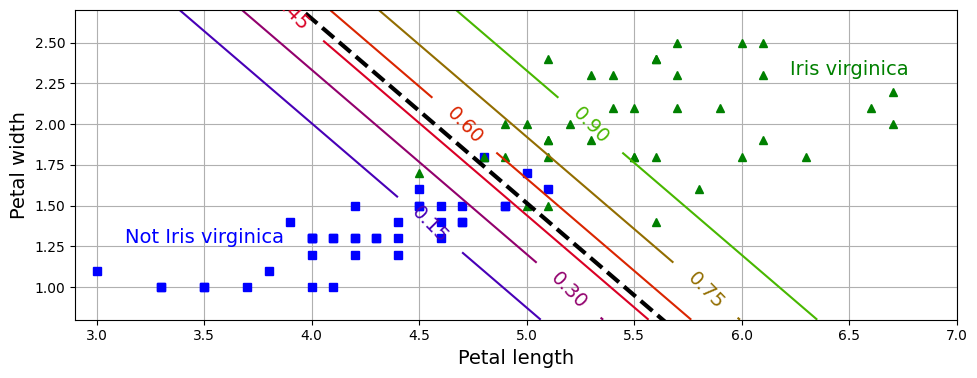

In [ ]:
# extra code – this cell generates and saves Figure 4–24

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
save_fig("logistic_regression_contour_plot")
plt.show()

Given the above code and the figure provided, how do l1 and l2 penalties apply to the Logistic regression model?
- Since l1 penalties have been decreased, the logistic regression model is better able to identify only the pertinent features. It lessens dimensionality and overfitting. Because the l2 penalty can be applied to large weights, it helps balance the data's variance and prevent overfitting in the model.

#### 3.7.3 Softmax Regression

The Logistic Regression model can be generalized to support multiple classes directly, without having to train and combine multiple binary classifiers. This is called Softmax Regression, or Multinomial Logistic Regression.

The idea is quite simple: when given an instance x, the Softmax Regression model first computes a score sk(x) for each class k, then estimates the probability of each
class by applying the somax function (also called the normalized exponential) to the scores. The equation to compute sk(x) should look familiar, as it is just like the equation for Linear Regression prediction

In [ ]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

In [ ]:
softmax_reg.predict([[5, 2]])

array([2])

In [ ]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])

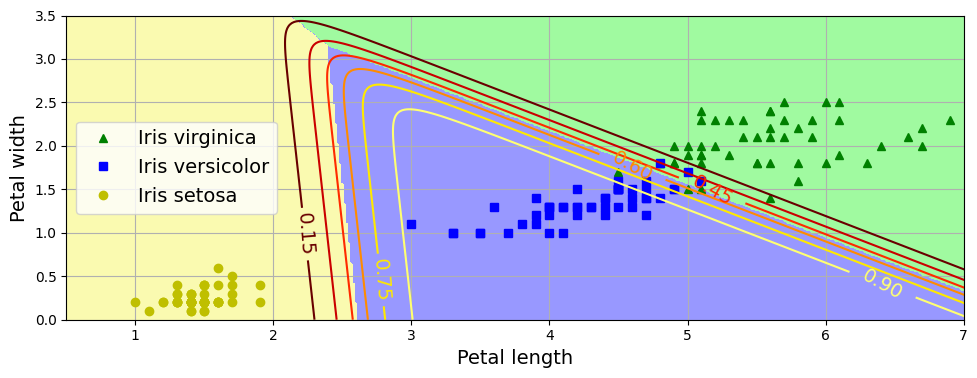

In [ ]:
# extra code – this cell generates and saves Figure 4–25

from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
save_fig("softmax_regression_contour_plot")
plt.show()

Given the code above as an example, how many classes can the Softmax Regression predict? Can it be used to on non-mutually exclusive classes (such as to recognize different faces in a picture)?
- One class that is mutually exclusive can be predicted by a Softmax regression. Since it works well when several classes can apply at once, it is not a useful analysis for non-mutually exclusive situations.

## 4. Supplementary Activity

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "Supplementary activity models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig2(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# In this part I need to create a image file for the copy of the visualization in a high resolution

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### <font size= 6><b>4.1 Linear Regression</b></font>

* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values.
* Perform descriptive statistics such as mean, median and mode
* Compute the correlation
* Use One-hot encoding in categorical features
* Apply feature scaling
* Perform linear regression using one independent variable only using numpy
* Perform linear regression using multiple independent variable using statsmodel
* Perform linear regression using sklearn



In [ ]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import SGDRegressor

<font size = 5>Import the dataset

In [ ]:
# Import the dataset
housing = pd.read_csv("/content/drive/MyDrive/BSCPE31S3-CPE312/Housing.csv")
housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


<font size = 5>Determine the number of datapoints, columns and data types

In [ ]:
# Determine the number of datapoints, columns and data types

print(f'Number of datapoints = {housing.shape[0]}')
print(f'Number of comlumns = {housing.shape[1]}')
print('\n')
housing.dtypes

Number of datapoints = 5000
Number of comlumns = 7




,0
Avg. Area Income,float64
Avg. Area House Age,float64
Avg. Area Number of Rooms,float64
Avg. Area Number of Bedrooms,float64
Area Population,float64
Price,float64
Address,object


In [ ]:
# Remove unneccesary columns
# since the address has nothing to do with linear regression we can simply remove it
housing = housing.drop(columns = ['Address'])
housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


<font size = 5>Do data cleaning such as removing empty values.

In [ ]:
# Do data cleaning such as removing empty values.

#find the total number of null values if there are
print(housing.isnull().sum())
# find if there are duplicated values
print(housing.duplicated().sum())
# rename specific column
housing.rename(columns={'Avg. Area Income': 'Area_Income',
                        'Avg. Area House Age':
                        'Area_House_Age',
                        'Avg. Area Number of Rooms':'Area_Number_Rooms',
                        'Avg. Area Number of Bedrooms':'Area_Number_Bedrooms',
                        'Area Population':'Area_Population'}, inplace=True)

housing.head()

# Since there are no missings or duplicated rows we can now move to descriptive statistics

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64
0


,Area_Income,Area_House_Age,Area_Number_Rooms,Area_Number_Bedrooms,Area_Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


<font size = 5>Perform descriptive statistics such as mean, median and mode

In [ ]:
# if we are going to observe the std, mean, and the min we can observe that there is a outliers in the dataset
# since the min value in Area_Income is really far for our natural data I think we can remove it
housing.describe().round(3)

,Area_Income,Area_House_Age,Area_Number_Rooms,Area_Number_Bedrooms,Area_Population,Price
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,68583.109,5.977,6.988,3.981,36163.516,1232072.654
std,10657.991,0.991,1.006,1.234,9925.650,353117.627
min,17796.631,2.644,3.236,2.000,172.611,15938.658
25%,61480.562,5.322,6.299,3.140,29403.929,997577.135
50%,68804.286,5.970,7.003,4.050,36199.407,1232669.378
75%,75783.339,6.651,7.666,4.490,42861.291,1471210.204
max,107701.748,9.519,10.760,6.500,69621.713,2469065.594


In [ ]:
# look
housing.sort_values('Area_Income').head()

,Area_Income,Area_House_Age,Area_Number_Rooms,Area_Number_Bedrooms,Area_Population,Price
39,17796.631190,4.949557,6.713905,2.50,47162.183643,3.023558e+05
3069,35454.714659,6.855708,6.018647,4.50,59636.402553,1.077806e+06
2092,35608.986237,6.935839,7.827589,6.35,20833.007623,4.493316e+05
4855,35797.323122,5.544221,7.795138,5.00,24844.200190,2.998630e+05
1459,35963.330809,3.438547,8.264122,3.28,24435.777302,1.430274e+05


In [ ]:
# I will drop it
min_index = housing['Area_Income'].idxmin()
housing = housing.drop(min_index)

In [ ]:
housing.describe()

,Area_Income,Area_House_Age,Area_Number_Rooms,Area_Number_Bedrooms,Area_Population,Price
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4.999000e+03
mean,68593.268311,5.977428,6.987847,3.981626,36161.315865,1.232259e+06
std,10634.817414,0.991449,1.005926,1.234083,9925.423573,3.529080e+05
min,35454.714659,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61481.724998,5.322350,6.299156,3.140000,29403.789820,9.977230e+05
50%,68805.020731,5.970953,7.002940,4.050000,36198.440991,1.232872e+06
75%,75784.342192,6.650870,7.666100,4.490000,42852.508761,1.471389e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


<font size = 5>Compute the correlation

In [ ]:
housing.corr().round(3)

,Area_Income,Area_House_Age,Area_Number_Rooms,Area_Number_Bedrooms,Area_Population,Price
Area_Income,1.000,-0.003,-0.011,0.019,-0.015,0.639
Area_House_Age,-0.003,1.000,-0.009,0.006,-0.019,0.452
Area_Number_Rooms,-0.011,-0.009,1.000,0.463,0.002,0.336
Area_Number_Bedrooms,0.019,0.006,0.463,1.000,-0.022,0.171
Area_Population,-0.015,-0.019,0.002,-0.022,1.000,0.409
Price,0.639,0.452,0.336,0.171,0.409,1.000


<font size= 5>Use One-hot encoding in categorical features

In [ ]:
# my dataset doest have categorical feature since address is unique per house

<font size = 5>Apply feature scaling

In [ ]:
# using the library In the sklearn I use the StandardScaler and Minmaxscaler for feature scaling

scale = StandardScaler()

# standard
X1 = housing.drop(columns = ["Price"])

X1_scale = scale.fit_transform(X1)
X1_scale
test1 = pd.DataFrame(X1_scale,columns = ['Area_Income',
 'Area_House_Age',
 'Area_Number_Rooms',
 'Area_Number_Bedrooms',
 'Area_Population',])

test1.head()

,Area_Income,Area_House_Age,Area_Number_Rooms,Area_Number_Bedrooms,Area_Population
0,1.029946,-0.297137,0.021218,0.087826,-1.317407
1,1.002033,0.025694,-0.255537,-0.722573,0.404230
2,-0.687076,-0.112511,1.516049,0.930641,0.072633
3,-0.493525,1.221374,-1.393003,-0.584806,-0.186517
4,-0.809787,-0.945048,0.846609,0.201282,-0.988188


In [ ]:
# Minmaxscaler
minmax_scaler = MinMaxScaler()
X2 = housing.drop(columns = ["Price"])
X2_scale = minmax_scaler.fit_transform(X2)
test2 = pd.DataFrame(X2_scale,columns = ['Area_Income',
 'Area_House_Age',
 'Area_Number_Rooms',
 'Area_Number_Bedrooms',
 'Area_Population',])
test2.head()

,Area_Income,Area_House_Age,Area_Number_Rooms,Area_Number_Bedrooms,Area_Population
0,0.610278,0.441986,0.501502,0.464444,0.329942
1,0.606169,0.488538,0.464501,0.242222,0.575968
2,0.357556,0.468609,0.701350,0.695556,0.528582
3,0.386044,0.660956,0.312430,0.280000,0.491549
4,0.339495,0.348556,0.611851,0.495556,0.376988


<font size= 5>Perform linear regression using one independent variable only using numpy

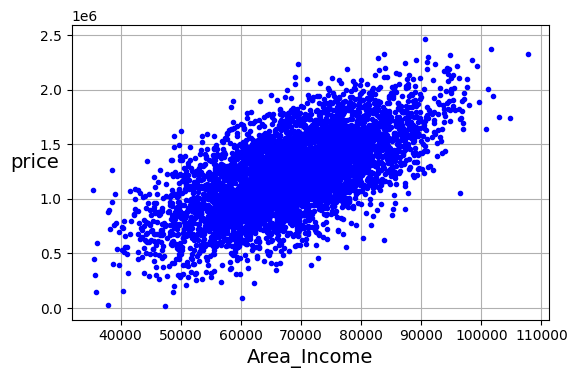

In [ ]:
# lets say that I choose the Area_Income as my independent variable for this task
from sklearn.preprocessing import add_dummy_feature
Area_Income = housing['Area_Income'].values.reshape(-1, 1)
Price = housing['Price'].values
plt.figure(figsize = (6,4))
plt.plot(Area_Income,Price,"b.")
plt.xlabel("Area_Income")
plt.ylabel("price", rotation = 0)
plt.grid()
save_fig2("4.1_numpy_plotdata")
plt.show()

In [ ]:
Income_b = add_dummy_feature(Area_Income)
theta_best = np.linalg.inv(Income_b.T @ Income_b) @ Income_b.T @ Price

In [ ]:
# I apply the Normal Equation formula in creating the linear regression

In [ ]:
theta_best

array([-2.22513250e+05,  2.12086684e+01])

In [ ]:
# just to make sure that my theta is not wrong I try using np library
theta_best_svd, residuals, rank, s = np.linalg.lstsq(Income_b, Price, rcond=1e-6)
theta_best_svd

array([-2.22513250e+05,  2.12086684e+01])

In [ ]:
Income_new = np.array([[housing['Area_Income'].min()], [housing['Area_Income'].max()]])
Income_new_b = add_dummy_feature(Income_new)
Price_predict = Income_new_b @ theta_best

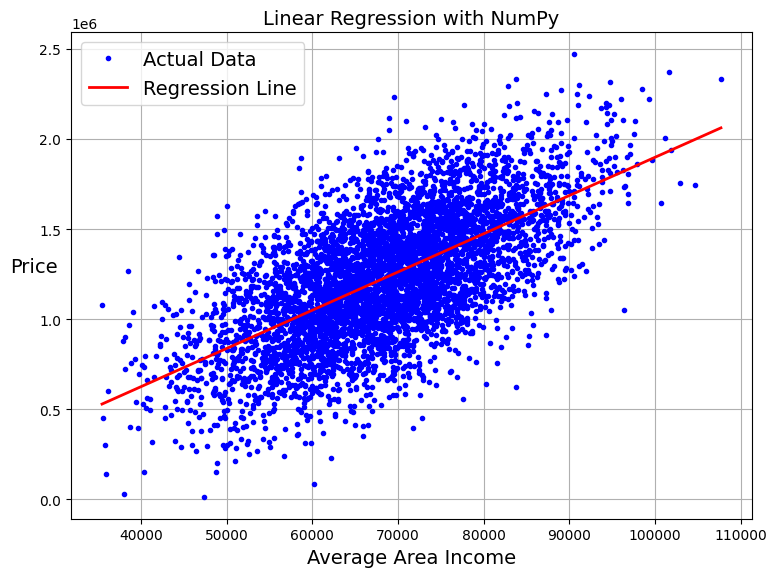

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(Area_Income, Price, "b.", label="Actual Data")  # scatter
plt.plot(Income_new, Price_predict, "r-", linewidth=2, label="Regression Line")  # regression line
plt.xlabel("Average Area Income")
plt.ylabel("Price", rotation=0)
plt.title("Linear Regression with NumPy")
plt.legend()
plt.grid(True)
save_fig2("linear_regression_using_numpy")
plt.show()

<font size= 5>Perform linear regression using multiple independent variable using statsmodel</font>

In [ ]:
# since I dont have background in using this library, so I search in the inter on how to use it


# Select independent variables I choose 3
X = housing[['Area_Income',
 'Area_House_Age',
 'Area_Number_Rooms',
 'Area_Number_Bedrooms',
 'Area_Population']]

# Dependent variable
y = housing["Price"]

# Add constant
X = sm.add_constant(X)

# Fitting the model
model = sm.OLS(y, X).fit()

# get the summary of the multiple independent linear regression
print(model.summary())

'''
Observation:

- Base on the results if we are going to observe Area_Number_Bedroms it has a p > 0001 which means that in predicting the price of the houses
Area_Number_Bedrooms is not a significant predictor
'''

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.118e+04
Date:                Mon, 18 Aug 2025   Prob (F-statistic):               0.00
Time:                        10:09:08   Log-Likelihood:                -64699.
No. Observations:                4999   AIC:                         1.294e+05
Df Residuals:                    4993   BIC:                         1.294e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -2.639e+06 

'\nObservation:\n\n- Base on the results if we are going to observe Area_Number_Bedroms it has a p > 0001 which means that in predicting the price of the houses\nArea_Number_Bedrooms is not a significant predictor\n'

<font size =5>Perform linear regression using sklearn

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


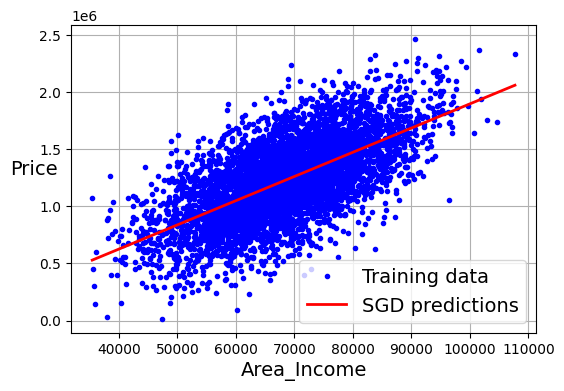

In [ ]:
# for the linear regression model using sklear
# I utilized the stochastic gradient descent model inorder to find the optimized solution
# I also use this one since we are dealing with alot of data


sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,n_iter_no_change=100, random_state=42)
sgd_reg.fit(Area_Income,Price.ravel())

plt.figure(figsize=(6,4))
plt.plot(Area_Income, Price, "b.", label="Training data")  # blue dots
plt.plot(Income_new, Price_predict, "r-", linewidth=2, label="SGD predictions")  # red line
plt.xlabel("Area_Income")
plt.ylabel("Price", rotation=0)
plt.legend()
plt.grid()
plt.show()

#### <font size= 6><b>4.2 Polynomial Regression</font></b>

* Choose your own dataset
* Import the dataset
* Perform polynomial regression using sklearn and polyfit
* Measure the performance for each polynomial degree.
* Plot the performance of the model for each polynomial degree.

In [ ]:
# import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

<font size =5>Choose your own dataset and Import the dataset</font>

In [ ]:
icecream_sales = pd.read_csv("/content/drive/MyDrive/BSCPE31S3-CPE312/Ice_cream selling data.csv")

In [ ]:
icecream_sales.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [ ]:
print(icecream_sales.shape)
print('\n')
print(icecream_sales.dtypes)
print('\n')
print(icecream_sales.isnull().sum())
print('\n')
print(icecream_sales.duplicated().sum())

(49, 2)


Temperature (°C)           float64
Ice Cream Sales (units)    float64
dtype: object


Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64


0


In [ ]:
icecream_sales.describe().round(3)

,Temperature (°C),Ice Cream Sales (units)
count,49.000,49.000
mean,0.272,15.905
std,2.698,12.265
min,-4.662,0.329
25%,-2.112,4.858
50%,0.689,12.615
75%,2.785,25.142
max,4.899,41.843


<font size= 5>Perform polynomial regression using sklearn and polyfit</font>

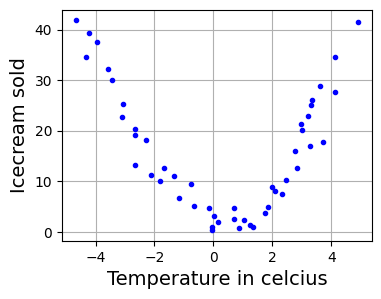

In [ ]:
# lets graph the data points first
X = icecream_sales['Temperature (°C)'].values.reshape(-1,1)
y = icecream_sales['Ice Cream Sales (units)']
plt.figure(figsize = (4,3))
plt.plot(X,y, "b.", label = "Training data")
plt.ylabel("Icecream sold")
plt.xlabel("Temperature in celcius")
plt.grid()
plt.show()

In [ ]:
# since its in U shape lets assume the degree that we are going to use is 2
degree = 2

#
poly_features = PolynomialFeatures(degree, include_bias=False)
X_poly = poly_features.fit_transform(X)
X_poly[0]

array([-4.66226268, 21.73669327])

In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
#lets find the coefficients and intercepts
print(f"Coefficients: {poly_model.coef_}")
print(f"Intercept: {poly_model.intercept_:.2f}")

Coefficients: [-0.82468167  1.82952623]
Intercept: 2.95


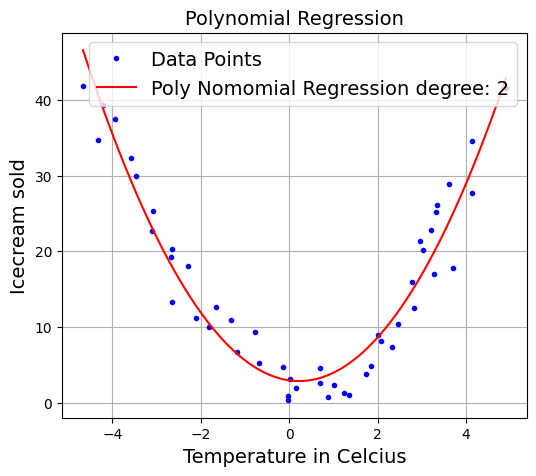

In [ ]:
# plotting the polynomial regression model along with the data points

x_range = np.linspace(X.min(),X.max(),300).reshape(-1,1)
x_range_poly = poly_features.transform(x_range)
y_range_predicted = poly_model.predict(x_range_poly)

plt.figure(figsize = (6,5))
plt.plot(X,y, "b.", label = "Data Points")
plt.plot(x_range,y_range_predicted, color = 'red', label = f"Poly Nomomial Regression degree: {degree}")
plt.xlabel("Temperature in Celcius")
plt.ylabel("Icecream sold")
plt.title("Polynomial Regression")
plt.grid()
plt.legend()
plt.show()

In [ ]:
# testing other temperature to predict icecream sold
x_test = np.array([[5]])
x_test_poly = poly_features.transform(x_test)
predicted_var = poly_model.predict(x_test_poly)
print(f"Predict target: {predicted_var[0]:.0f}")

Predict target: 45


<font size = 5>Measure the performance for each polynomial degree.</font>

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# In this part we are goig to test the performance of poly nomial model when we increasing our degree

# applying the concept from the previous module wherein we learn how to split data set into test and training set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# testing different polynomial degree
degrees = [1, 2, 5, 10, 20]
results = []

for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    model = make_pipeline(poly_features, StandardScaler(), LinearRegression())
    model.fit(X_train, y_train)

    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    results.append((degree, train_mse, test_mse, r2))

# save the results as a dataframe for better visuals
df_results = pd.DataFrame(results, columns=["Degree", "Train MSE", "Test MSE", "R² (Test)"])

df_results.head()


#Observing the results as the degree increases the predictions in the training set becomes accurate
#But when we try it into the unseen data set it misses everything
# which results to overfitting model

,Degree,Train MSE,Test MSE,R² (Test)
0,1,143.331601,149.326291,-0.575127
1,2,8.995868,14.878796,0.843055
2,5,5.749212,21.030820,0.778162
3,10,4.272613,24.335878,0.743300
4,20,2.921088,7353.809357,-76.569621


<font size = 5>Plot the performance of the model for each polynomial degree.</font>

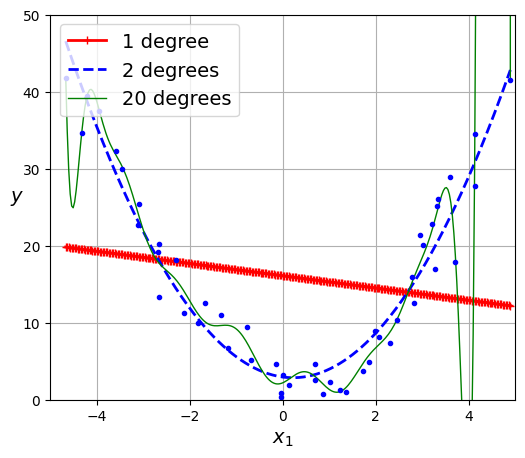

In [ ]:
# Using the code from the procedure
# the gree line represents the overfitting model wherein it  follows every training set
# the red line represents underfitting wherein it just draw a straight line all over the graph and didnt match any of the data points
# blue represents the correct tuning of the model
X_new = np.linspace(X.min(),X.max(),300).reshape(-1,1)

plt.figure(figsize=(6, 5))

for style, width, degree in (("r-+", 2, 1), ("b--", 2, 2), ("g-", 1, 20)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)

    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-5, 5, 0, 50])
plt.grid()
plt.show()

#### <font size= 6><b>4.3 Logistic Regression</font></b>

* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values(NaN), replacing missing data .
* Perform descriptive statistics such as mean, median and mode
* Perform data visualization
* Solve classification problem using Logistic Regression
* Evaluate the model using classification report, accuracy and confusion matrix

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

<font size= 5>Choose your own dataset and Import the dataset</font>

In [ ]:
# Import the dataset
titanic = pd.read_csv("/content/drive/MyDrive/BSCPE31S3-CPE312/Titanic-Dataset.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

<font size = 5>Determine the number of datapoints, columns and data types</font>

In [ ]:
print(f'Number of rows: {titanic.shape[0]}')
print(f'Number of columns: {titanic.shape[1]}')
print('\n')
print(f'============ Data types ============')
print(titanic.dtypes)

# we can observed that the age and family size is in float format even it should be discrete
titanic['Age'] = titanic['Age'].astype('int64')
#However we cant also change it since there are null values for sure so lets clean first

Number of rows: 891
Number of columns: 12


============ Data types ============
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

<font size= 5>Remove unneccesary columns</font>

In [ ]:
# when it comes to removing the unnecessary columns
# the only thing that doesnt affect our predictions are the Unnamed column and the PassengerId
# so we remove it

titanic = titanic.drop(columns = ['PassengerId','Name','Ticket','Cabin',])

<font size =5>Do data cleaning such as removing empty values(NaN), replacing missing data .</font>

In [ ]:
# lets move to the cleaning first thing is we determine if there are empty rows

print(f'Number of empty values : {titanic.isnull().sum()}')
# we can observed that there are 3 duplicated rows
print(f'Number of duplicates : {titanic.duplicated().sum()}')

# lets drop duplicate values
print('\n')
titanic.drop_duplicates(inplace =True)
print(f'Number of duplicates : {titanic.duplicated().sum()}')
# drop the nulls in embarked

Number of empty values : Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
Number of duplicates : 111


Number of duplicates : 0


In [ ]:
#Filling empty values in age
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
# droping the 2 Embarked empty
titanic = titanic.dropna(subset=['Embarked'])

In [ ]:
titanic.isnull().sum()
# We have now a clean data

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


<font size = 5>Perform descriptive statistics such as mean, median and mode</font>

In [ ]:
# lets check for outliers using the descriptive statistics
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000
mean,0.411311,2.249357,29.518535,0.526992,0.419023,34.712987
std,0.492388,0.853206,13.687558,0.988956,0.839346,52.280326
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.250000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,33.890600
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<font size= 5>Perform data visualization</font>

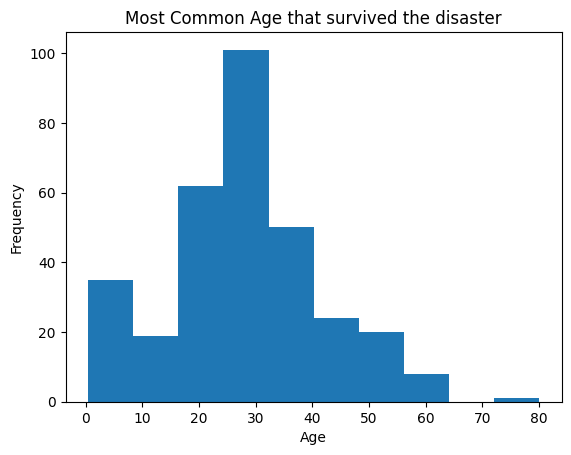

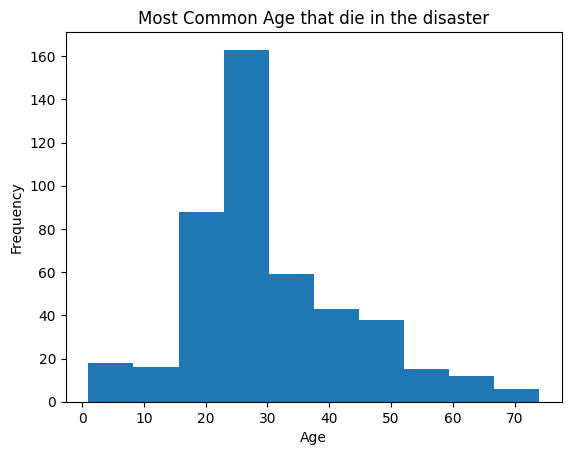

In [ ]:
# Im wondering of what is the common age of passenger that survived the disaster
Survived = titanic[titanic['Survived'] == 1]
Dead = titanic[titanic['Survived'] == 0]
Survived['Age'].plot(kind = 'hist')
plt.title('Most Common Age that survived the disaster')
plt.xlabel('Age')
plt.show()

# It appears that young to middle age people has survived the disaster


Dead['Age'].plot(kind = 'hist')
plt.title('Most Common Age that die in the disaster')
plt.xlabel('Age')
plt.show()

# It appears that middle to old age people have died in the disaster

In [ ]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


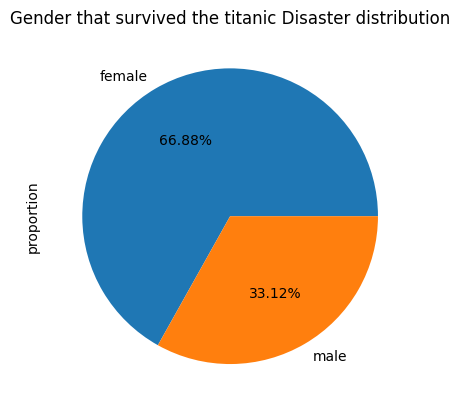

In [ ]:
# Determine the most gender that survived the disaster

Gender = Survived['Sex'].value_counts(normalize= True)
Gender

Gender.plot(kind = 'pie', autopct = '%1.2f%%')
plt.title("Gender that survived the titanic Disaster distribution")
plt.show()

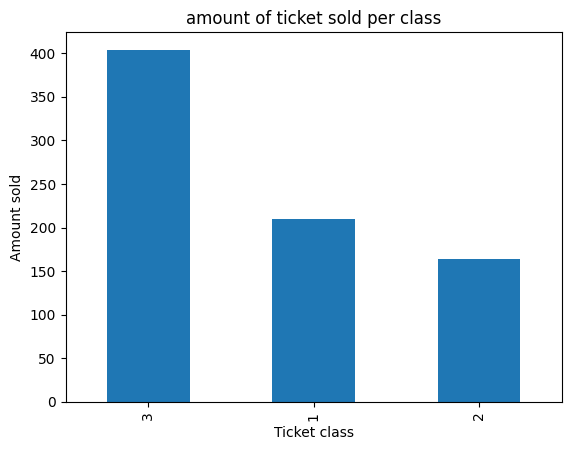

In [52]:
# Find the most sold ticket class

sold_ticket = titanic['Pclass'].value_counts()
sold_ticket.plot(kind = 'bar')
plt.title("amount of ticket sold per class")
plt.xlabel("Ticket class")
plt.ylabel("Amount sold")
plt.show()

<font size =5>Solve classification problem using Logistic Regression</font>

In [ ]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [40]:
X_age = titanic[['Fare']].values
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X_age, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [41]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]  # probability of survival

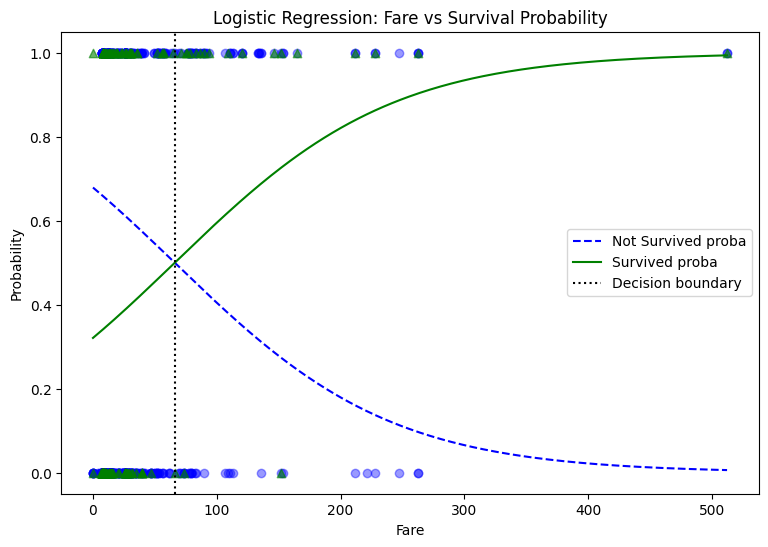

In [44]:
# Range of Fare values
fare_range = np.linspace(X_age.min(), X_age.max(), 300).reshape(-1, 1)

# Predicted probabilities using the fare_range
probs = log_reg.predict_proba(fare_range)

plt.figure(figsize=(9,6))

# Plot probability of not survived with blue double hypen lines
plt.plot(fare_range, probs[:,0], "b--", label="Not Survived proba")

# Plot probability of surived with green solid line
plt.plot(fare_range, probs[:,1], "g-", label="Survived proba")

# graphing the decision boundary wherin  probal falls to 0.5
decision_boundary = -log_reg.intercept_[0] / log_reg.coef_[0][0]
plt.axvline(x=decision_boundary, color="k", linestyle=":", label="Decision boundary")

# Plot training points along with the test sets
# training data = blue dots
# test data = green dots
plt.scatter(X_train, y_train, marker="o", c="blue", alpha=0.4)
plt.scatter(X_test, y_test, marker="^", c="green", alpha=0.6)

plt.xlabel("Fare")
plt.ylabel("Probability")
plt.title("Logistic Regression: Fare vs Survival Probability")
plt.legend()
plt.show()

<font size = 5>Evaluate the model using classification report, accuracy and confusion matrix</font>

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.6730769230769231
Confusion Matrix:
 [[88  3]
 [48 17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.97      0.78        91
           1       0.85      0.26      0.40        65

    accuracy                           0.67       156
   macro avg       0.75      0.61      0.59       156
weighted avg       0.73      0.67      0.62       156

ROC AUC: 0.7426035502958579


In [ ]:
# Base on the results my ROC AUC is 0.74 which is not good enough
# Since I only use one predictor which is the Fare

<font size =5><b>Utilizing multiple parameter in logistic regression

In [46]:
X = titanic[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]
y = titanic['Survived']

# Using One-hot encoding in categorical values: Sex and Embarked
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Evaluate
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.7628205128205128
Confusion Matrix:
 [[75 16]
 [21 44]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80        91
           1       0.73      0.68      0.70        65

    accuracy                           0.76       156
   macro avg       0.76      0.75      0.75       156
weighted avg       0.76      0.76      0.76       156

ROC AUC: 0.8112426035502958


In [ ]:
'''
Observation:

- If im going to use 1 predictor it might lead to under fitting because it is too simple and weak based on the result of previous output.
However, if we are going to add parameter we should be aware that it is relevant to the case of the dataset. Based on the result above,
after adding paramets we can see that the model is able to classify survivors compared to the previous model. the reason that I do 1 parameter
is just to make a visualization. I cant graph multiple parameters.

'''

## <font size =5><b>5. Summary, Conclusions and Lessons Learned</font></b>

 - After completing the procedure in this activity, I was able to learned and used different kinds of models in machine learning such as the linear regression model, polynomial regression model, and the logistic regresion model. I was able to apply it in diffrent kinds of dataset in the supplementary activity. Additionally, I was able learn and use the 3 kinds of gradient descent wherein it helps in finding the best or optimized solution in our model. During the procedure and the supplementary activity, I was having hardtime understanding all the concept specially in the code part where the application of the model happens. Since Im not used to skilearn library and I didnt know what happens inside the matrix when we are applying the mathematical equation using the numpy library specially in the normal equation part. Overall, I can say that I should do more training with different kinds of datasets in the kaggle to enhance my skills.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*

***Disclaimer***

*Contents of this Notebook are based on Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow 3rd Edition by Aurelien Geron.*
*A copy of the complete text can be obtained here: https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/*